Objetivo:
Previsão de Preços de Casas

### Crie um dataset único a partir dos datasets em anexo.

### 1. Análise e entendimento dos dados
- Explique o que representam as principais variáveis.
- Mostre correlações, outliers e padrões relevantes.
- Descreva como combinou os dados físicos e demográficos.

### 2. Desenvolvimento do modelo de Machine Learning
Inclua:
- **a. Variáveis importantes:** quais features foram mais relevantes e por quê.
- **b. Escolha do modelo:** escolha e implemente um modelo para resolver o problema --- Lembre-se que a NP1 englobou até MLP.
- **c. Generalização:** como você garante que o modelo generaliza bem para novos dados (ex: uso de *train/test split*, *cross-validation*, regularização, etc.).

O aluno deve entregar um relatório explicando os passos solicitados e o código contando todas as etapas de EDA, Pré-Processamento, Implementação do Modelo.

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

from sklearn.model_selection import KFold

In [2]:
df_demog = pd.read_csv('datasets/zipcode_demographics.csv', delimiter=',')
df_house = pd.read_csv('datasets/kc_house_data.csv', delimiter=',')
df_future = pd.read_csv('datasets/future_unseen_examples.csv', delimiter=',')

df = df_house.merge(df_demog, on='zipcode', how='left')
df_future = df_future.merge(df_demog, on='zipcode', how='left')
df.to_csv('datasets/dataframe.csv', index=False)
df_future.to_csv('datasets/dataframe_future.csv', index=False)

print(df.shape)
print(df.isnull().sum())
print(df.describe())

(21613, 47)
id                        0
date                      0
price                     0
bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
yr_renovated              0
zipcode                   0
lat                       0
long                      0
sqft_living15             0
sqft_lot15                0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
hous_val_amt              0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_pr

In [3]:
# renovated: True / False
df['renovated'] = df['yr_renovated'] > 0
df_future['renovated'] = df_future['yr_renovated'] > 0
# basement: True / False
df['basement'] = df['sqft_basement'] > 0
df_future['basement'] = df_future['sqft_basement'] > 0
# diferença entre a regiao
df['dif_sqft_living'] = df['sqft_living'] - df['sqft_living15']
df['dif_sqft_lot'] = df['sqft_lot'] - df['sqft_lot15']

df_future['dif_sqft_living'] = df_future['sqft_living'] - df_future['sqft_living15']
df_future['dif_sqft_lot'] = df_future['sqft_lot'] - df_future['sqft_lot15']

print(df.head)
print(df_future.head())

<bound method NDFrame.head of                id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0         2       0.75   
21611   291310100  20150116T000000  400000.0         3       2.50   
21612  1523300157  20141015T000000  325000.0         2       0.75   

       sqft_living  sqft_lot  floors  waterfront  view  ...  per_9_to_12  \
0             1180      5650     1.0           0     0  ...      

In [4]:
# removendo o que não interessa ou causa data leakage ou foi substituído/informação duplicada
df.drop(columns=['date',
                 'sqft_living15',
                 'sqft_lot15',
                 'zipcode',
                 'hous_val_amt',
                 'id',
                 'yr_renovated'
                 ], inplace=True)
print(df.shape)
print(df.isnull().sum())
df_future.drop(columns=[
    'sqft_living15',
    'sqft_lot15',
    'zipcode',
    'yr_renovated'
], inplace=True)

(21613, 44)
price                     0
bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
lat                       0
long                      0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_prfsnl_qty          0
per_urbn                  0
per_sbrbn                 0
per_farm                  0
per_non_farm              0
per_less_than_9           0
per_9_to_12               0
per_hsd 

In [5]:
# outliers
detectar_outlier = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_basement',
    'medn_hshld_incm_amt',
    'medn_incm_per_prsn_amt',
    'dif_sqft_living',
    'dif_sqft_lot',
]
df_outlier = df[detectar_outlier]

z_scores = np.abs((df_outlier - df_outlier.mean()) / df_outlier.std())
outliers = (z_scores > 3)
print(outliers.sum())
df_outlier[outliers].to_csv('datasets/outliers_zscore.csv', index=False)
print(df_outlier[outliers].describe())

print('\n')

Q1 = df_outlier.quantile(0.25)
Q3 = df_outlier.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_outlier < (Q1 - 1.5 * IQR)) | (df_outlier > (Q3 + 1.5 * IQR)))
print(outliers.sum())
df_outlier[outliers].to_csv('datasets/outliers_iqr.csv', index=False)
print(df_outlier[outliers].describe())

price                     406
bedrooms                   75
bathrooms                 187
sqft_living               248
sqft_lot                  347
sqft_above                254
sqft_basement             247
medn_hshld_incm_amt        50
medn_incm_per_prsn_amt     50
dif_sqft_living           340
dif_sqft_lot              244
dtype: int64
              price   bedrooms   bathrooms   sqft_living      sqft_lot  \
count  4.060000e+02  75.000000  187.000000    248.000000  3.470000e+02   
mean   2.276499e+06   6.640000    4.902406   5823.685484  2.716364e+05   
std    7.685827e+05   4.323537    0.663088   1120.504588  1.687333e+05   
min    1.646000e+06   0.000000    4.500000   4850.000000  1.393920e+05   
25%    1.791212e+06   7.000000    4.500000   5127.500000  1.995965e+05   
50%    2.000000e+06   7.000000    4.500000   5480.000000  2.178000e+05   
75%    2.496250e+06   8.000000    5.000000   6070.000000  2.697905e+05   
max    7.700000e+06  33.000000    8.000000  13540.000000  1.65135

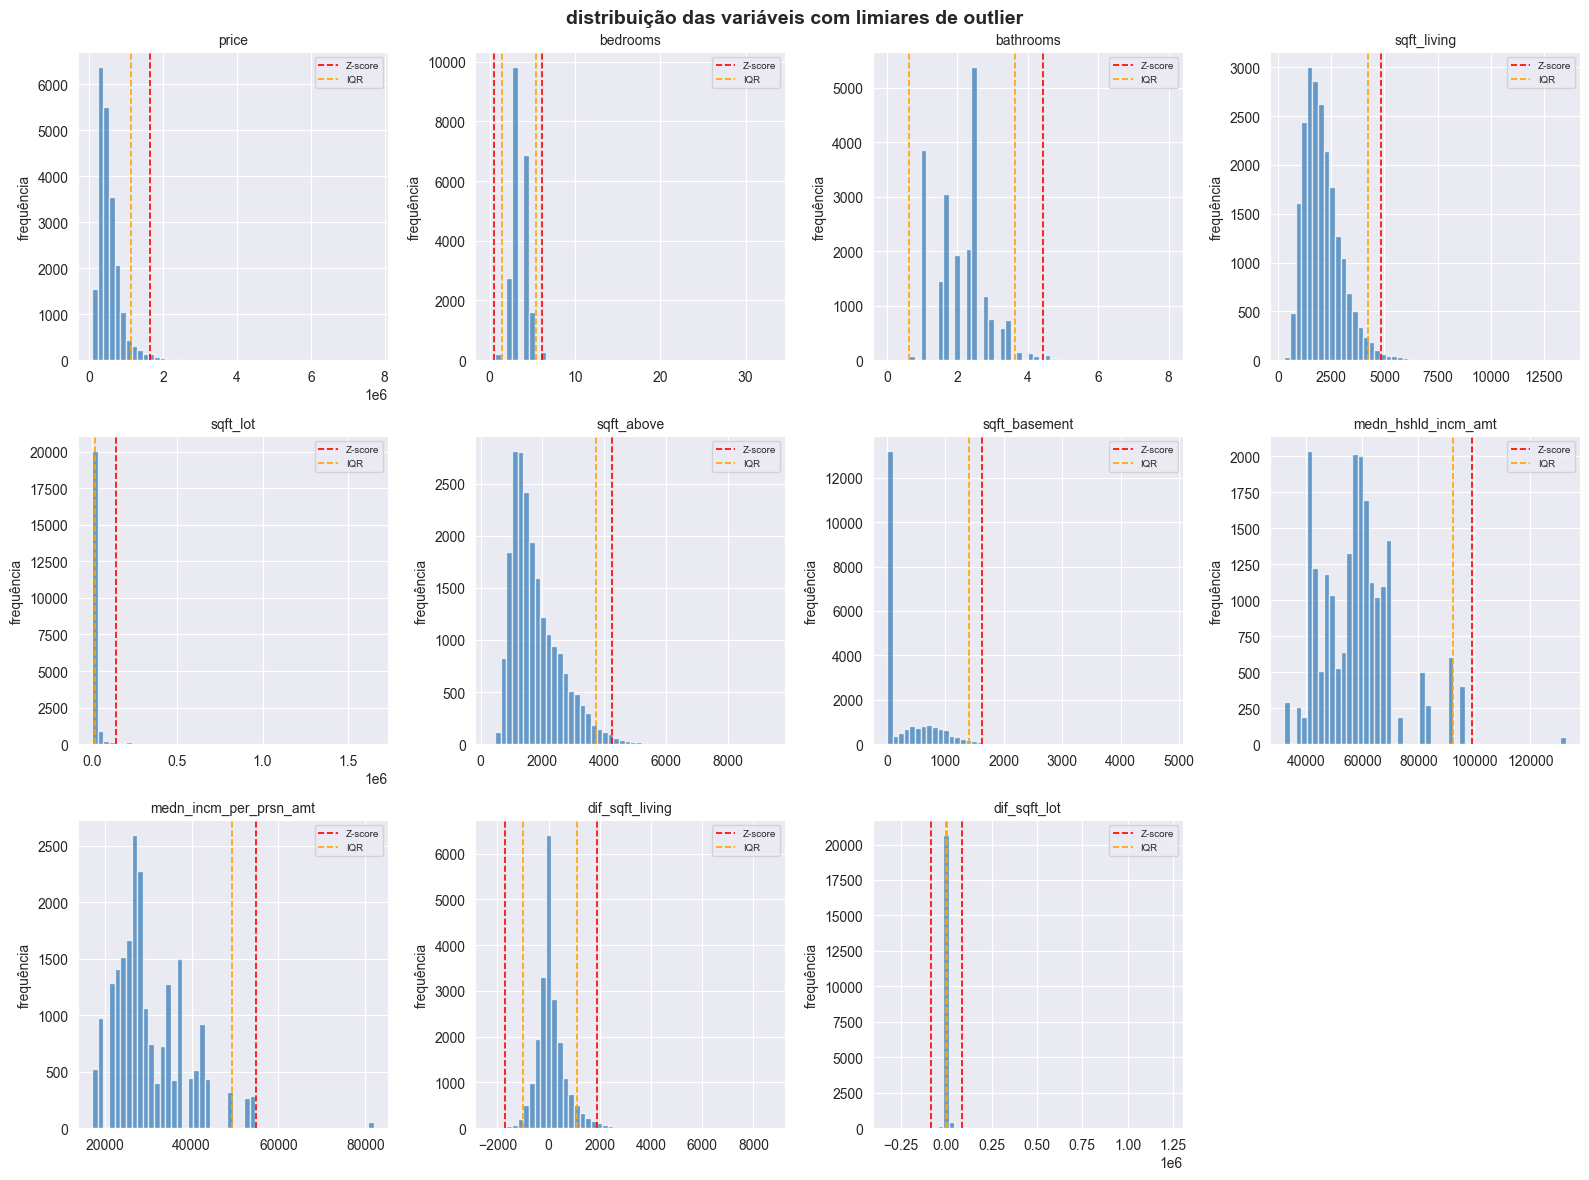

In [6]:
# histogramas com limiar de outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("distribuição das variáveis com limiares de outlier", fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(detectar_outlier):
    ax = axes_flat[i]
    data = df_outlier[col].dropna()

    # limiares z-score
    mean, std = data.mean(), data.std()
    z_low, z_high = mean - 3*std, mean + 3*std

    # limiares IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_low, iqr_high = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    ax.hist(data, bins=50, color='#2E75B6', alpha=0.7, edgecolor='white')
    ax.axvline(z_high,   color='red',    linestyle='--', linewidth=1.2, label='Z-score')
    ax.axvline(iqr_high, color='orange', linestyle='--', linewidth=1.2, label='IQR')

    # limiar inferior se > mínimo dos dados
    if z_low > data.min():
        ax.axvline(z_low,  color='red',    linestyle='--', linewidth=1.2)
    if iqr_low > data.min():
        ax.axvline(iqr_low, color='orange', linestyle='--', linewidth=1.2)

    ax.set_title(col, fontsize=10)
    ax.set_ylabel("frequência")
    ax.legend(fontsize=7)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

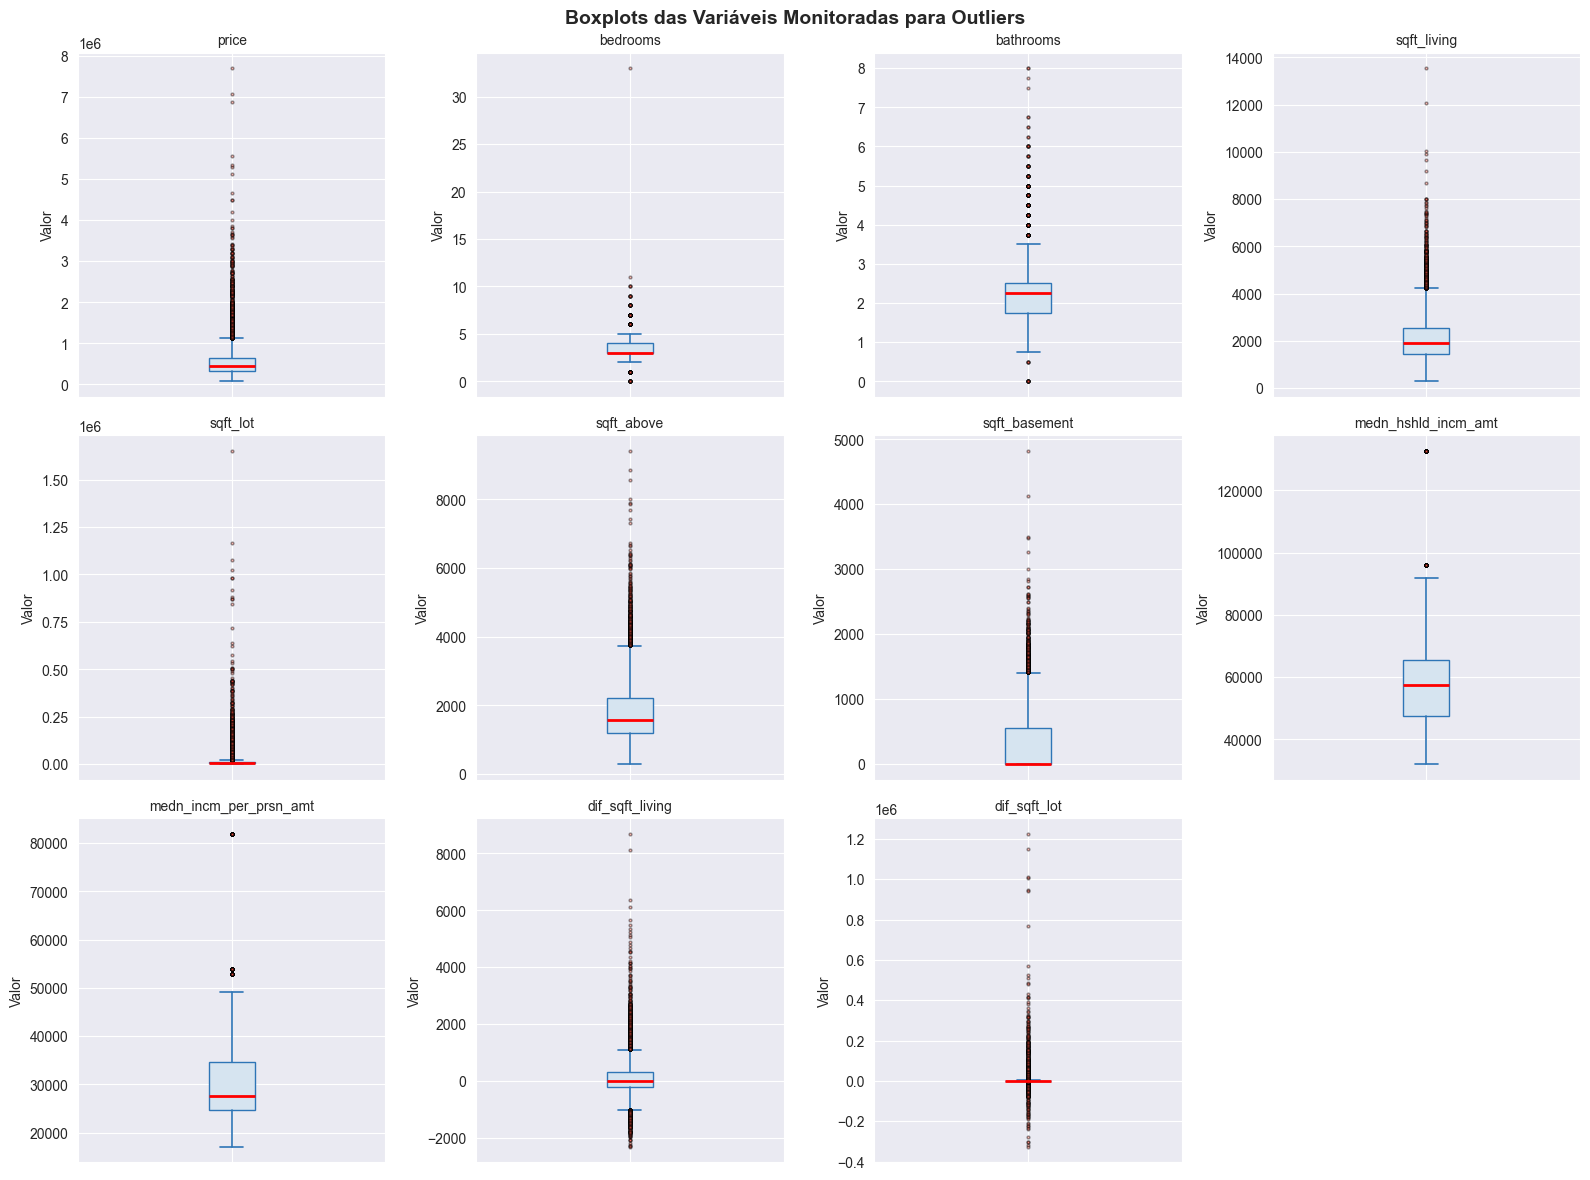

In [7]:
# boxplots por variável
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Boxplots das Variáveis Monitoradas para Outliers", fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(detectar_outlier):
    ax = axes_flat[i]
    data = df_outlier[col].dropna()

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#D6E4F0', color='#2E75B6'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#2E75B6', linewidth=1.2),
               capprops=dict(color='#2E75B6', linewidth=1.2),
               flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                               markersize=2, alpha=0.4, linestyle='none'))

    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Valor")
    ax.tick_params(axis='x', labelbottom=False)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
# removendo outlier de 'bedrooms' por KNN
df.loc[df['bedrooms'] == 33, 'bedrooms'] = np.nan
imputer = KNNImputer(n_neighbors=5)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

                           price
price                   1.000000
sqft_living             0.702035
grade                   0.667434
sqft_above              0.605567
medn_incm_per_prsn_amt  0.549911
bathrooms               0.525138
per_prfsnl              0.500262
per_bchlr               0.474896
dif_sqft_living         0.405392
view                    0.397293
sqft_basement           0.323816
bedrooms                0.315434
lat                     0.307003
edctn_prfsnl_qty        0.291694
medn_hshld_incm_amt     0.272460
waterfront              0.266369
floors                  0.256794
edctn_bchlr_dgre_qty    0.209238
basement                0.180230
renovated               0.126092
sqft_lot                0.089661
per_urbn                0.068983
yr_built                0.054012
dif_sqft_lot            0.050591
condition               0.036362
long                    0.021626
per_sbrbn              -0.023602
sbrbn_ppltn_qty        -0.028090
per_farm               -0.062706
per_non_fa

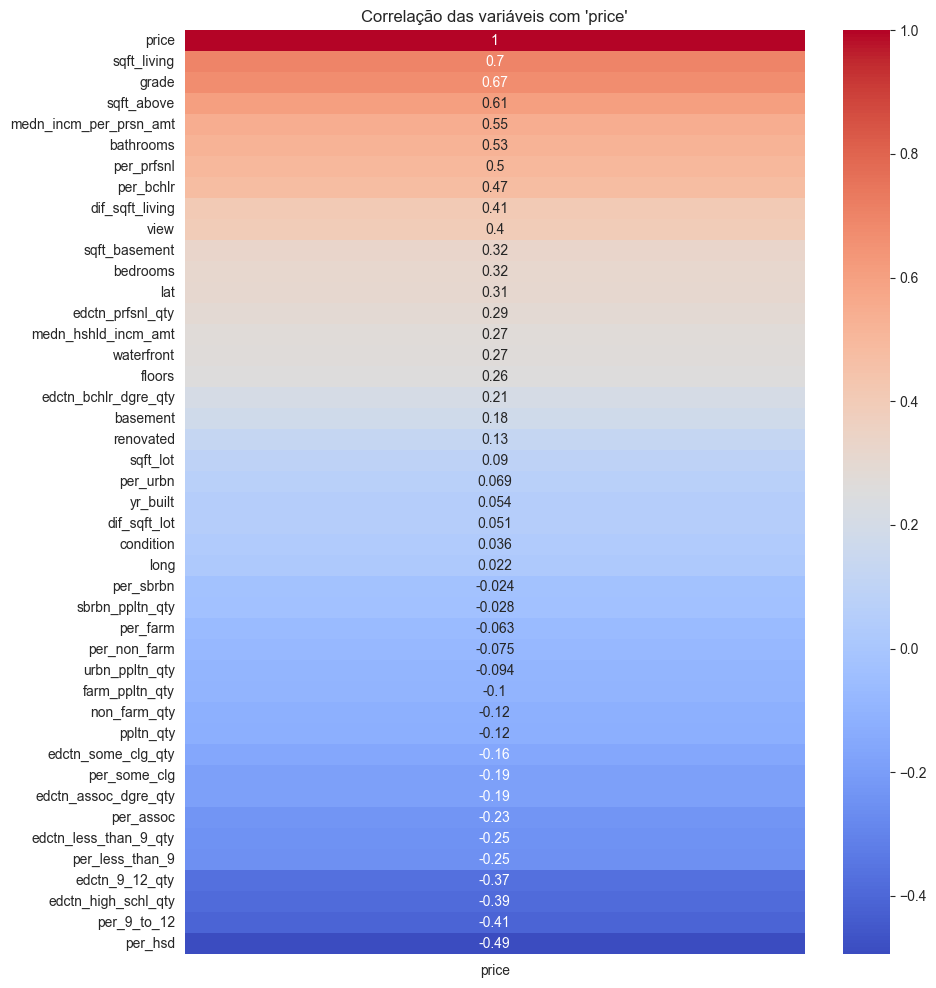

In [9]:
# correlação
price_corr = df.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False)
print(price_corr)

plt.figure(figsize=(10,12))
sns.heatmap(price_corr, annot=True, cmap='coolwarm')
plt.title("Correlação das variáveis com 'price'")
plt.show()


In [10]:
# features
features = [
    "sqft_living",
    "grade",
    "sqft_above",
    "medn_incm_per_prsn_amt",
    "bathrooms",
    "per_prfsnl",
    "per_bchlr",
    "dif_sqft_living",
    "view",
    "sqft_basement",
    "bedrooms",
    "lat",
    "medn_hshld_incm_amt",
    "waterfront",
    "floors",
    "basement",
    "renovated",
    "sqft_lot",
    "per_urbn",
    "dif_sqft_lot",
    "condition",
    "long",
    "yr_built",
    "per_assoc",
    "per_9_to_12",
    "per_hsd"
    ]

X = df[features]
y = df['price']

In [11]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
print(y_train.min())
print(y_train.max())
print(y_train.mean())

75000.0
7700000.0
537768.04794679


### Escolha do modelo

Modelos lineares foram descartados pela natureza não-linear das relações entre área, localização e preço. O MLP é o modelo mais complexo dentro do escopo estudado e é tecnicamente adequado para o problema.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 410984677376.0000 - mae: 531061.6250 - rmse: 641080.8750 - val_loss: 333524107264.0000 - val_mae: 496992.0312 - val_rmse: 577515.4375
Epoch 2/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 207884435456.0000 - mae: 372446.1562 - rmse: 455943.4688 - val_loss: 84017020928.0000 - val_mae: 246677.2500 - val_rmse: 289856.9062
Epoch 3/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 73572704256.0000 - mae: 216812.2344 - rmse: 271242.8750 - val_loss: 52463362048.0000 - val_mae: 180590.4219 - val_rmse: 229048.8125
Epoch 4/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49348677632.0000 - mae: 164164.4219 - rmse: 222145.6250 - val_loss: 37250265088.0000 - val_mae: 142739.6250 - val_rmse: 193003.2812
Epoch 5/100
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39447003136.0000 - mae: 139400.8906 - rmse: 198612.7031 - val_loss: 31736059904.0000 - val_mae: 128502.0156 - val_rmse: 178146.1719
Epoch 6/100
487/487 ━━━━━━━

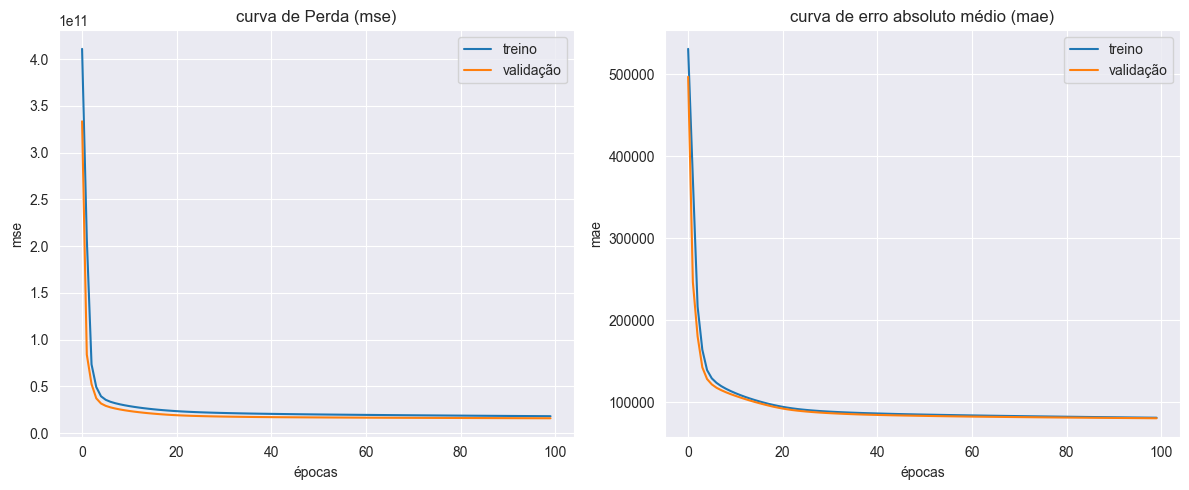

In [14]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

print(model.summary())

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'), tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, mae, rmse = model.evaluate(X_test_scaled, y_test)
print(f'mae: ${mae:,.0f}')
print(f'rmse: ${rmse:,.0f}')

y_pred = model.predict(X_test_scaled).flatten()
r2 = r2_score(y_test, y_pred)
print(f'r2_score: {r2:.4f}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('curva de Perda (mse)')
plt.xlabel('épocas')
plt.ylabel('mse')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='treino')
plt.plot(history.history['val_mae'], label='validação')
plt.title('curva de erro absoluto médio (mae)')
plt.xlabel('épocas')
plt.ylabel('mae')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
df_future = df_future[features]
df_future_scaled = scaler.transform(df_future)
future_pred = model.predict(df_future_scaled).flatten()
df_future['price'] = future_pred
print(df_future.head())
df_future.to_csv("datasets/future_prices.csv", index=False)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
   sqft_living  grade  sqft_above  medn_incm_per_prsn_amt  bathrooms  \
0         1680      6        1680                 19414.0       1.00   
1         2220      8        1660                 34026.0       2.50   
2         1630      8        1100                 27639.5       2.25   
3         1710      8        1710                 36019.0       2.50   
4          850      6         850                 25844.0       1.00   

   per_prfsnl  per_bchlr  dif_sqft_living  view  sqft_basement  ...  sqft_lot  \
0         6.0       11.0              120     0              0  ...      5043   
1        20.0       30.0             1270     0            560  ...      6380   
2         7.5       19.0             -200     0            530  ...     10962   
3        16.0       26.0             -560     0              0  ...      9720   
4         7.0       16.0                0     0              0  ...      6370   

   per_urbn  dif_sqft_lot  condition     l

Avaliação com K-Fold

In [16]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for i, (treino, val) in enumerate(kfold.split(X)):
    print(f"Fold {i+1}/5", end=" ")

    model = keras.Sequential([
        layers.Dense(64, 'relu', input_shape=(X.shape[1],)),
        layers.Dense(32, 'relu'),
        layers.Dense(16, 'relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    model.fit(scaler.transform(X.iloc[treino]), y.iloc[treino],
              epochs=50, batch_size=32, verbose=0)

    pred = model.predict(scaler.transform(X.iloc[val]), verbose=0).flatten()
    mae = np.mean(np.abs(y.iloc[val] - pred))
    resultados.append(mae)

    print(f"MAE: ${mae:,.0f}")

print(f"MAE médio nos 5 folds: ${np.mean(resultados):,.0f}")
print(f"desvio padrão:         ${np.std(resultados):,.0f}")

Fold 1/5... 

C:\Users\beatr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: $89,036
Fold 2/5... 

C:\Users\beatr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: $86,115
Fold 3/5... 

...

MAE: $82,028
Fold 4/5... 

C:\Users\beatr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: $85,347
Fold 5/5... 

C:\Users\beatr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: $84,111
MAE médio nos 5 folds: $85,327
desvio padrão:         $2,313
